# Fraction prediction and bioactivity visualization

This notebook is the **visualization layer** for `fraction_core_v2.py`.

It can work in two modes:

1. **Run the core from the notebook** using a config.
2. **Reuse an existing run** by loading `run_summary.json`.

The goal is to keep all heavy processing in the core script and use the notebook only for:
- QC
- summary tables
- calibration plots
- fraction-level bioactivity plots
- feature-level summaries for each target plant

In [7]:
# -----------------------------
# User settings — edit this cell
# -----------------------------
from pathlib import Path

BASE_DIR = Path.cwd()

# Put the notebook next to p_04_00_fraction_predictor_core.py, or point this to the file directly.
CORE_SCRIPT = BASE_DIR / "p_04_00_fraction_predictor_core.py"

# Choose how the config is provided:
#   "json"   -> load CONFIG_PATH
#   "inline" -> use INLINE_CONFIG from the next cell
CONFIG_MODE = "json"

# Recommended: use a config JSON saved from CLI/GUI.
CONFIG_PATH = BASE_DIR / "example_fraction_config.json"

# Set to True if you want the notebook to run the core itself.
# Set to False if you already have Outputs/run_summary.json and only want plotting/QC.
RUN_CORE = False

# Optional explicit summary path.
# If None, the notebook will try BASE_DIR / output_dir / run_summary.json.
SUMMARY_PATH = None

# Notebook output options
SAVE_FIGURES = True
FIGURE_DIRNAME = "Notebook_figures"
TOP_N_FEATURES = 20
DISPLAY_ROWS = 20

# Whether tables of "top features" should include only rows with signal in the given plant sample column.
SHOW_ONLY_PRESENT_FEATURES = True

In [8]:
# -----------------------------
# Optional inline config template
# -----------------------------
# Use this only if CONFIG_MODE = "inline".
# It mirrors the JSON structure expected by fraction_core_v2.py.

INLINE_CONFIG = {
    "output_dir": "Outputs",
    "predicted_rt_column": "predicted_hplc_rt",
    "feature_table": {
        "path": "data/Tropicana_tito_final_new_quant.csv",
        "id_column": "row ID",
        "mz_column": "row m/z",
        "rt_column": "row retention time",
        "area_threshold": 10000,
        "sample_columns": [
            "20240813_58_s84t1_1uL.mzML Peak area",
            "20240813_60_s86t1_1uL.mzML Peak area",
        ],
    },
    "calibration": {
        "method": "pairs",
        "pairs_file": "data/manual_guesses.xlsx",
        "uplc_rt_column": "84_86 row retention time",
        "hplc_rt_column": "HPLC rt",
        "minimum_points": 2,
        "recommended_points": 5,
    },
    "fractions": {
        "start_time": 2.0,
        "end_time": 38.0,
        "n_fractions": 96,
        "first_fraction_number": 1,
    },
    "bioactivity": {
        "cutoffs": [16.5, 22.5],
    },
    "plants": [
        {
            "name": "Macleaya microcarpa",
            "sample_column": "20240813_58_s84t1_1uL.mzML Peak area",
            "fluorescence_file": "data/fractions_84_UV_clean.xlsx",
            "fluorescence_fraction_column": "fraction",
            "fluorescence_average_column": "average",
            "fluorescence_positive_control_column": "pos_avg",
        },
        {
            "name": "Macleaya cordata",
            "sample_column": "20240813_60_s86t1_1uL.mzML Peak area",
            "fluorescence_file": "data/fractions_86_UV_clean.xlsx",
            "fluorescence_fraction_column": "fraction",
            "fluorescence_average_column": "average",
            "fluorescence_positive_control_column": "pos_avg",
        },
    ],
    "append_to_feature_table": {
        "path": "data/feature_table_everything.csv",
        "id_column": "row ID",
    },
}

In [9]:
# -----------------------------
# Imports + core import
# -----------------------------
import copy
import importlib.util
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

if not CORE_SCRIPT.exists():
    raise FileNotFoundError(
        f"Could not find core script: {CORE_SCRIPT}\n"
        "Place the notebook next to p_04_00_fraction_predictor_core.py or update CORE_SCRIPT."
    )

spec = importlib.util.spec_from_file_location("p_04_00_fraction_predictor_core", CORE_SCRIPT)
fc = importlib.util.module_from_spec(spec)
sys.modules["p_04_00_fraction_predictor_core"] = fc
spec.loader.exec_module(fc)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [10]:
# -----------------------------
# Resolve config + run/load pipeline
# -----------------------------
def load_config():
    mode = str(CONFIG_MODE).strip().lower()
    if mode == "json":
        if not Path(CONFIG_PATH).exists():
            raise FileNotFoundError(f"Config JSON not found: {CONFIG_PATH}")
        with open(CONFIG_PATH, "r", encoding="utf-8") as handle:
            config = json.load(handle)
    elif mode == "inline":
        config = copy.deepcopy(INLINE_CONFIG)
    else:
        raise ValueError("CONFIG_MODE must be 'json' or 'inline'.")
    config.setdefault("base_dir", str(BASE_DIR))
    return config

config = load_config()
output_dir = Path(config.get("base_dir", BASE_DIR)) / config.get("output_dir", "Outputs")

if RUN_CORE:
    summary = fc.run_pipeline(config)
    summary_path = Path(summary["output_dir"]) / "run_summary.json"
else:
    if SUMMARY_PATH is not None:
        summary_path = Path(SUMMARY_PATH)
    else:
        summary_path = output_dir / "run_summary.json"
    if not summary_path.exists():
        raise FileNotFoundError(
            f"run_summary.json not found: {summary_path}\n"
            "Either run the core first or set RUN_CORE = True."
        )
    with open(summary_path, "r", encoding="utf-8") as handle:
        summary = json.load(handle)

figure_dir = Path(summary["output_dir"]) / FIGURE_DIRNAME
if SAVE_FIGURES:
    figure_dir.mkdir(parents=True, exist_ok=True)

display(Markdown(f"**Using output directory:** `{summary['output_dir']}`"))
display(Markdown(f"**Summary file:** `{summary_path}`"))

**Using output directory:** `C:\Users\bouch\Desktop\IOCB_Erik\PROJECTS\microfractionation\revision\scripts\python\04_fraction_predictor\Outputs`

**Summary file:** `c:\Users\bouch\Desktop\IOCB_Erik\PROJECTS\microfractionation\revision\scripts\python\04_fraction_predictor\Outputs\run_summary.json`

In [11]:
# -----------------------------
# Load tables from summary
# -----------------------------
files = summary["files"]

filtered_df = fc.read_table(files["filtered_feature_table"])
fraction_df = fc.read_table(files["fraction_windows"])
predicted_df = fc.read_table(files["features_with_fraction_predictions"])
combined_df = fc.read_table(files["features_with_bioactivity"])

appended_df = None
if "appended_feature_table" in files:
    appended_df = fc.read_table(files["appended_feature_table"])

plant_tables = {}
for plant_info in summary["plants"]:
    plant_tables[plant_info["name"]] = fc.read_table(plant_info["file"])

feature_cfg = config["feature_table"]
resolved_id_column = summary["resolved_id_column"]
mz_column = feature_cfg.get("mz_column", "row m/z")
rt_column = feature_cfg.get("rt_column", "row retention time")
predicted_rt_column = config.get("predicted_rt_column", "predicted_hplc_rt")
cutoffs = [float(x) for x in config.get("bioactivity", {}).get("cutoffs", [])]

display(Markdown(
    f"Loaded **{len(filtered_df):,} filtered features**, "
    f"**{len(fraction_df):,} fractions**, and "
    f"**{len(summary['plants'])} plant bioactivity table(s)**."
))

Loaded **2,929 filtered features**, **96 fractions**, and **2 plant bioactivity table(s)**.

In [12]:
# -----------------------------
# Helper functions for plotting/QC
# -----------------------------
def maybe_savefig(fig, stem):
    if not SAVE_FIGURES:
        return None
    path = figure_dir / f"{fc.slugify(stem)}.png"
    fig.savefig(path, bbox_inches="tight")
    return path


def parse_fraction_list(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    text = str(value).strip()
    if not text:
        return []
    return [int(x) for x in str(text).split(";") if str(x).strip()]


def count_features_per_fraction(df, parsed_col="parsed_fraction_numbers"):
    counts = {}
    for value in df[parsed_col]:
        for frac in parse_fraction_list(value):
            counts[frac] = counts.get(frac, 0) + 1
    if not counts:
        return pd.DataFrame(columns=["fraction", "feature_count"])
    return (
        pd.DataFrame({"fraction": list(counts.keys()), "feature_count": list(counts.values())})
        .sort_values("fraction")
        .reset_index(drop=True)
    )


def plot_calibration(config, summary, reference_df):
    cal = summary["calibration"]
    method = str(cal.get("method", "equation")).lower()

    fig, ax = plt.subplots(figsize=(6.2, 4.4))
    x_line = None

    if method == "pairs" and "pairs_file" in config["calibration"]:
        pairs_path = fc.resolve_path(config.get("base_dir", BASE_DIR), config["calibration"]["pairs_file"])
        pairs_df = fc.read_table(pairs_path)
        x_col = config["calibration"]["uplc_rt_column"]
        y_col = config["calibration"]["hplc_rt_column"]
        x = pd.to_numeric(pairs_df[x_col], errors="coerce")
        y = pd.to_numeric(pairs_df[y_col], errors="coerce")
        mask = x.notna() & y.notna()
        x = x[mask]
        y = y[mask]
        ax.scatter(x, y, s=40, label="Calibration pairs")
        if not x.empty:
            x_line = np.linspace(float(x.min()), float(x.max()), 200)
    else:
        x = pd.to_numeric(reference_df[rt_column], errors="coerce").dropna()
        if not x.empty:
            x_line = np.linspace(float(x.min()), float(x.max()), 200)

    if x_line is None:
        x_line = np.linspace(0, float(config["fractions"]["end_time"]), 200)

    y_line = cal["slope"] * x_line + cal["intercept"]
    ax.plot(x_line, y_line, linewidth=2, label="Calibration fit")

    label = (
        f"y = {cal['slope']:.6g}x + {cal['intercept']:.6g}\n"
        f"method = {cal.get('method', 'unknown')}"
    )
    if cal.get("r_squared") is not None:
        label += f"\nR² = {cal['r_squared']:.4f}"
    if cal.get("n_points") is not None:
        label += f"\nn = {cal['n_points']}"

    ax.text(
        0.02, 0.98, label,
        transform=ax.transAxes,
        va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    )
    ax.set_xlabel(cal.get("x_label", "UPLC retention time"))
    ax.set_ylabel(cal.get("y_label", "HPLC retention time"))
    ax.set_title("Retention-time calibration")
    ax.legend()
    ax.grid(True, alpha=0.25)

    path = maybe_savefig(fig, "01_retention_time_calibration")
    if path:
        display(Markdown(f"Saved figure: `{path}`"))
    plt.show()


def plot_fraction_feature_counts(predicted_df):
    counts_df = count_features_per_fraction(predicted_df)
    if counts_df.empty:
        print("No parsed fraction assignments were found.")
        return counts_df

    fig, ax = plt.subplots(figsize=(9, 4.2))
    ax.bar(counts_df["fraction"], counts_df["feature_count"], width=0.85)
    ax.set_xlabel("Fraction number")
    ax.set_ylabel("Number of assigned features")
    ax.set_title("Feature counts per predicted fraction")
    ax.grid(True, axis="y", alpha=0.25)

    path = maybe_savefig(fig, "02_feature_counts_per_fraction")
    if path:
        display(Markdown(f"Saved figure: `{path}`"))
    plt.show()
    return counts_df


def plot_bioactivity_by_fraction(plant_df, plant_name, cutoffs):
    fraction_col = next(
        (c for c in plant_df.columns if str(c).strip().lower() in {"fraction", "fraction#", "fraction_number"}),
        None,
    )
    if fraction_col is None:
        raise KeyError(f"Could not find a fraction column in plant table for {plant_name}.")

    df = plant_df.copy()
    df[fraction_col] = pd.to_numeric(df[fraction_col], errors="coerce")
    df["bioactivity"] = pd.to_numeric(df["bioactivity"], errors="coerce")
    df = df.dropna(subset=[fraction_col, "bioactivity"]).sort_values(fraction_col)

    fig, ax = plt.subplots(figsize=(10, 4.2))
    ax.bar(df[fraction_col], df["bioactivity"], width=0.85)
    for cutoff in sorted(cutoffs):
        ax.axhline(cutoff, linestyle="--", linewidth=1)
    ax.set_xlabel("Fraction number")
    ax.set_ylabel("Bioactivity")
    ax.set_title(f"Bioactivity by fraction — {plant_name}")
    ax.grid(True, axis="y", alpha=0.25)

    path = maybe_savefig(fig, f"bioactivity_by_fraction_{plant_name}")
    if path:
        display(Markdown(f"Saved figure: `{path}`"))
    plt.show()


def plot_group_counts_for_plant(combined_df, plant_cfg, cutoffs, only_present=True):
    plant_name = plant_cfg["name"]
    slug = fc.slugify(plant_name)
    group_col = f"bioactivity_group_{slug}"
    sample_col = plant_cfg.get("sample_column")

    if group_col not in combined_df.columns:
        print(f"Column not found: {group_col}")
        return pd.DataFrame()

    df = combined_df.copy()

    if only_present and sample_col and sample_col in df.columns:
        present = pd.to_numeric(df[sample_col], errors="coerce").fillna(0) > 0
        df = df.loc[present].copy()

    order = fc.make_group_labels(cutoffs) + ["No data"]
    counts = df[group_col].fillna("No data").value_counts()
    counts = pd.Series({label: int(counts.get(label, 0)) for label in order}, name="feature_count")
    counts_df = counts.rename_axis("group").reset_index()

    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ax.bar(counts_df["group"], counts_df["feature_count"])
    ax.set_xlabel("Bioactivity group")
    ax.set_ylabel("Number of features")
    ax.set_title(f"Feature counts by bioactivity group — {plant_name}")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(True, axis="y", alpha=0.25)

    path = maybe_savefig(fig, f"group_counts_{plant_name}")
    if path:
        display(Markdown(f"Saved figure: `{path}`"))
    plt.show()
    return counts_df


def top_features_for_plant(combined_df, plant_cfg, top_n=20, only_present=True):
    plant_name = plant_cfg["name"]
    slug = fc.slugify(plant_name)
    group_col = f"bioactivity_group_{slug}"
    value_col = f"bioactivity_value_{slug}"
    sample_col = plant_cfg.get("sample_column")

    needed = [resolved_id_column, mz_column, rt_column, predicted_rt_column, "matched_fraction", group_col, value_col]
    keep = [c for c in needed if c in combined_df.columns]

    if sample_col and sample_col in combined_df.columns:
        keep.append(sample_col)

    df = combined_df[keep].copy()

    if only_present and sample_col and sample_col in df.columns:
        present = pd.to_numeric(df[sample_col], errors="coerce").fillna(0) > 0
        df = df.loc[present].copy()

    if value_col in df.columns:
        df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
        df = df.sort_values([value_col, predicted_rt_column], ascending=[False, True], na_position="last")

    return df.head(top_n).reset_index(drop=True)

## Run summary

The next cell gives a compact QC overview before plotting:
- calibration summary
- filtering summary
- preview of the final feature table

In [13]:
summary_table = pd.DataFrame(
    [
        ("Input feature rows", summary["n_rows_input"]),
        ("Filtered feature rows", summary["n_rows_filtered"]),
        ("Resolved ID column", summary["resolved_id_column"]),
        ("Generated ID column", summary["generated_id_column"]),
        ("Calibration method", summary["calibration"]["method"]),
        ("Calibration slope", summary["calibration"]["slope"]),
        ("Calibration intercept", summary["calibration"]["intercept"]),
        ("Output directory", summary["output_dir"]),
    ],
    columns=["Item", "Value"],
)
display(summary_table)

display(Markdown("### Preview of final feature table"))
display(combined_df.head(DISPLAY_ROWS))

,Item,Value
0,Input feature rows,40013
1,Filtered feature rows,2929
2,Resolved ID column,row ID
3,Generated ID column,False
4,Calibration method,pairs
5,Calibration slope,1.722772
6,Calibration intercept,-1.025485
7,Output directory,C:\Users\bouch\Desktop\IOCB_Erik\PROJECTS\micr...


### Preview of final feature table

,row ID,row m/z,row retention time,row ion mobility,row ion mobility unit,row CCS,correlation group ID,annotation network number,best ion,auto MS2 verify,...,Unnamed: 158,predicted_hplc_rt,matched_fraction,parsed_fraction_numbers,bioactivity_group_Macleaya_cordata,bioactivity_value_Macleaya_cordata,present_in_Macleaya_cordata,bioactivity_group_Macleaya_microcarpa,bioactivity_value_Macleaya_microcarpa,present_in_Macleaya_microcarpa
0,5,272.941954,0.878170,NaN,NaN,NaN,107.0,NaN,NaN,NaN,...,NaN,0.487401,Fraction not collected,NaN,No data,NaN,True,No data,NaN,True
1,6,244.946856,0.878590,NaN,NaN,NaN,107.0,NaN,NaN,NaN,...,NaN,0.488124,Fraction not collected,NaN,No data,NaN,True,No data,NaN,True
2,7,221.931033,0.879292,NaN,NaN,NaN,107.0,NaN,NaN,NaN,...,NaN,0.489334,Fraction not collected,NaN,No data,NaN,True,No data,NaN,True
3,8,249.925763,0.879479,NaN,NaN,NaN,107.0,NaN,NaN,NaN,...,NaN,0.489656,Fraction not collected,NaN,No data,NaN,True,No data,NaN,True
4,16,385.875790,0.889121,NaN,NaN,NaN,107.0,NaN,NaN,NaN,...,NaN,0.506267,Fraction not collected,NaN,No data,NaN,True,No data,NaN,True
5,17,413.870882,0.891170,NaN,NaN,NaN,107.0,NaN,NaN,NaN,...,NaN,0.509798,Fraction not collected,NaN,No data,NaN,True,No data,NaN,True
6,18,333.878426,0.894248,NaN,NaN,NaN,107.0,NaN,NaN,NaN,...,NaN,0.515100,Fraction not collected,NaN,No data,NaN,True,No data,NaN,True
7,19,429.848601,0.894440,NaN,NaN,NaN,107.0,NaN,NaN,NaN,...,NaN,0.515431,Fraction not collected,NaN,No data,NaN,True,No data,NaN,True
8,23,286.958704,0.895837,NaN,NaN,NaN,107.0,16.0,[M-H2O+K]+,NaN,...,NaN,0.517838,Fraction not collected,NaN,No data,NaN,True,No data,NaN,True
9,26,401.940401,0.897459,NaN,NaN,NaN,107.0,NaN,NaN,NaN,...,NaN,0.520631,Fraction not collected,NaN,No data,NaN,True,No data,NaN,True


## Global QC plots

These are workflow-level plots:
- retention-time calibration
- feature counts per predicted fraction

Saved figure: `C:\Users\bouch\Desktop\IOCB_Erik\PROJECTS\microfractionation\revision\scripts\python\04_fraction_predictor\Outputs\Notebook_figures\01_retention_time_calibration.png`

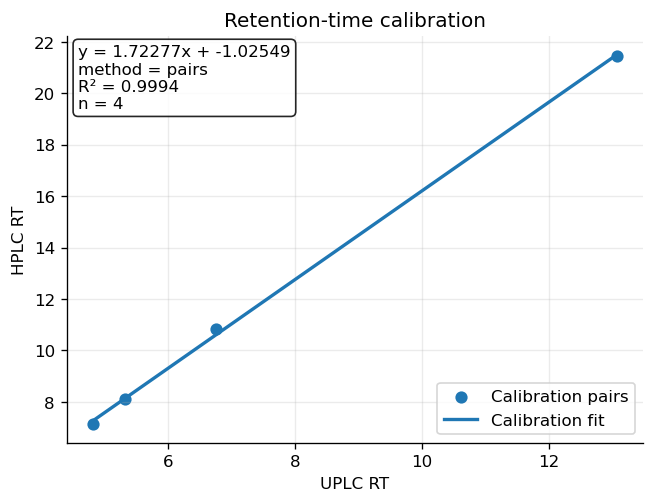

Saved figure: `C:\Users\bouch\Desktop\IOCB_Erik\PROJECTS\microfractionation\revision\scripts\python\04_fraction_predictor\Outputs\Notebook_figures\02_feature_counts_per_fraction.png`

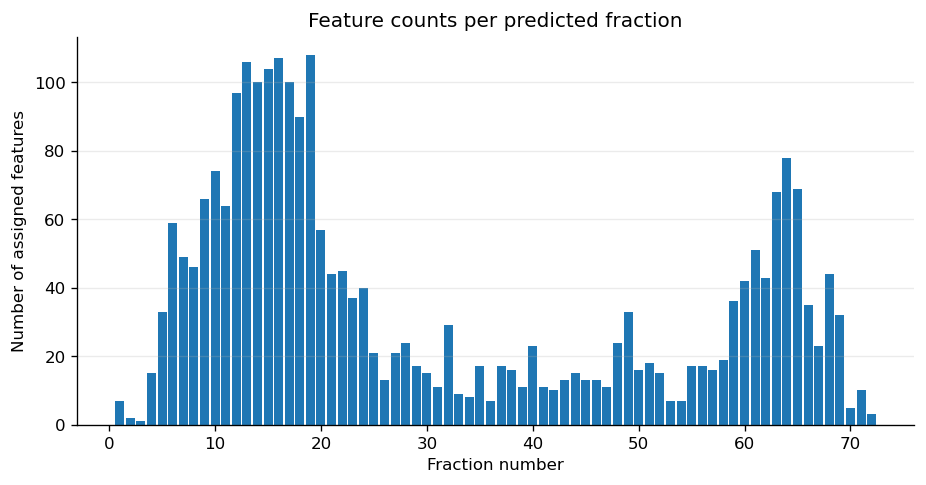

### Fraction counts table

,fraction,feature_count
0,1,7
1,2,2
2,3,1
3,4,15
4,5,33
5,6,59
6,7,49
7,8,46
8,9,66
9,10,74


In [14]:
plot_calibration(config, summary, predicted_df)

predicted_for_counts = predicted_df.copy()

def _normalize_fraction_numbers(value):
	if pd.isna(value):
		return np.nan
	parts = [p.strip() for p in str(value).split(";") if p.strip()]
	cleaned = []
	for p in parts:
		try:
			cleaned.append(str(int(float(p))))
		except ValueError:
			continue
	return ";".join(cleaned) if cleaned else np.nan

predicted_for_counts["parsed_fraction_numbers"] = predicted_for_counts["parsed_fraction_numbers"].apply(
	_normalize_fraction_numbers
)

fraction_count_table = plot_fraction_feature_counts(predicted_for_counts)

display(Markdown("### Fraction counts table"))
display(fraction_count_table.head(DISPLAY_ROWS))

## Plant-specific plots and top features

For each plant, the notebook shows:
- bioactivity by fraction
- number of mapped features in each bioactivity group
- a compact table of the top features

## Macleaya microcarpa

### Fraction-level bioactivity

Saved figure: `C:\Users\bouch\Desktop\IOCB_Erik\PROJECTS\microfractionation\revision\scripts\python\04_fraction_predictor\Outputs\Notebook_figures\bioactivity_by_fraction_Macleaya_microcarpa.png`

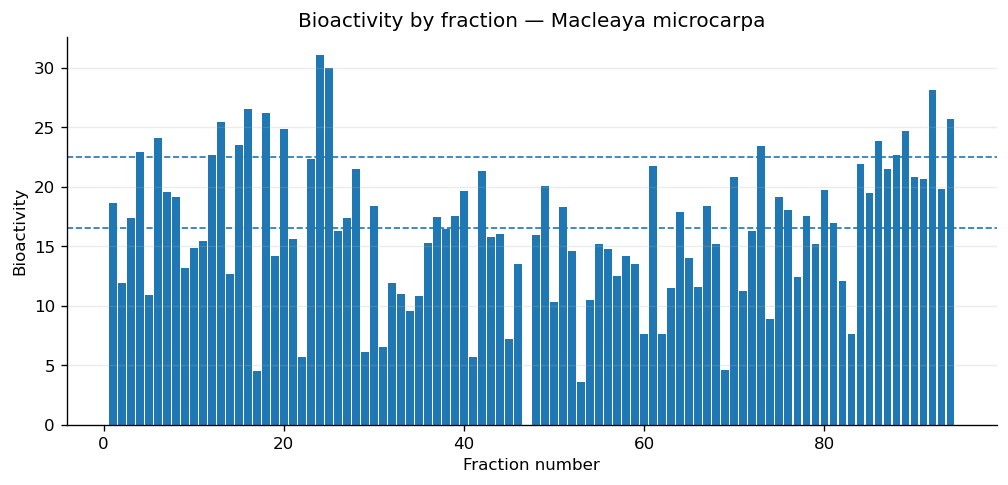

### Feature counts by bioactivity group

Saved figure: `C:\Users\bouch\Desktop\IOCB_Erik\PROJECTS\microfractionation\revision\scripts\python\04_fraction_predictor\Outputs\Notebook_figures\group_counts_Macleaya_microcarpa.png`

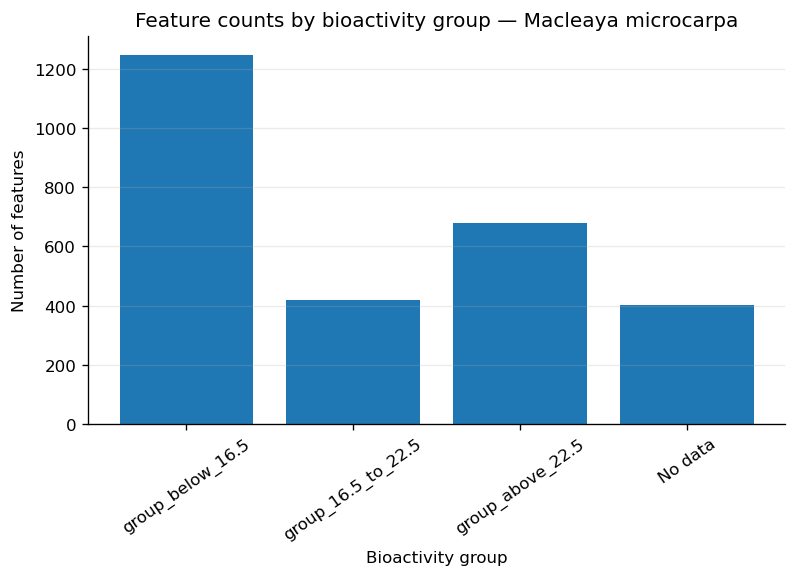

,group,feature_count
0,group_below_16.5,1248
1,group_16.5_to_22.5,418
2,group_above_22.5,680
3,No data,402


### Top mapped features

,row ID,row m/z,row retention time,predicted_hplc_rt,matched_fraction,bioactivity_group_Macleaya_microcarpa,bioactivity_value_Macleaya_microcarpa,20240813_58_s84t1_1uL.mzML Peak area
0,22885,392.076280,6.769664,10.637101,24,group_above_22.5,31.059093,25367.8870
1,22897,370.165010,6.773008,10.642862,24,group_above_22.5,31.059093,410211.4700
2,22906,378.097220,6.774414,10.645283,24,group_above_22.5,31.059093,298899.8400
3,22917,522.291619,6.776009,10.648031,24,group_above_22.5,31.059093,1094.4402
4,22936,593.187434,6.778961,10.653117,24,group_above_22.5,31.059093,12367.2460
5,22937,336.122572,6.779013,10.653206,24,group_above_22.5,31.059093,860092.4400
6,22963,337.126869,6.781874,10.658135,24,group_above_22.5,31.059093,183941.2200
7,22999,342.068850,6.788640,10.669792,24,group_above_22.5,31.059093,14755.8240
8,23122,374.159720,6.808639,10.704246,24,group_above_22.5,31.059093,11998.8210
9,23152,354.133653,6.814638,10.714580,24,group_above_22.5,31.059093,287611.2200


## Macleaya cordata

### Fraction-level bioactivity

Saved figure: `C:\Users\bouch\Desktop\IOCB_Erik\PROJECTS\microfractionation\revision\scripts\python\04_fraction_predictor\Outputs\Notebook_figures\bioactivity_by_fraction_Macleaya_cordata.png`

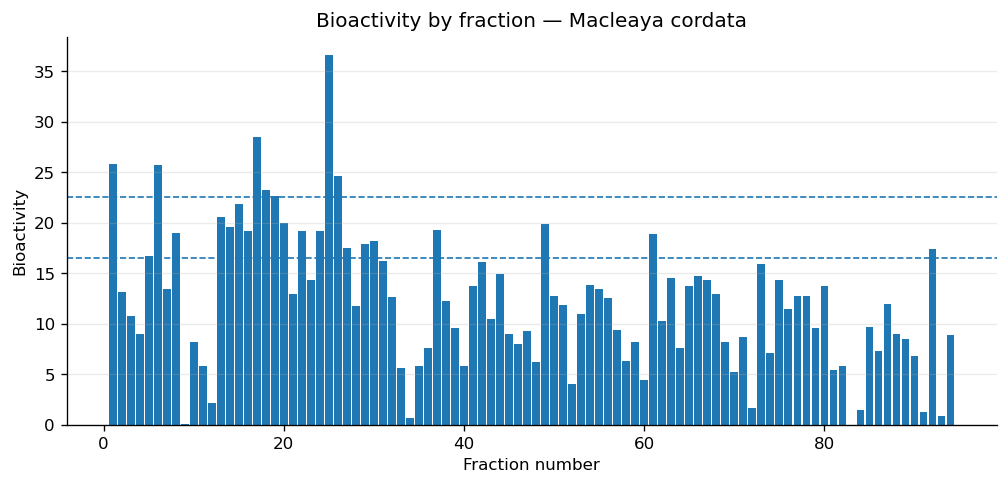

### Feature counts by bioactivity group

Saved figure: `C:\Users\bouch\Desktop\IOCB_Erik\PROJECTS\microfractionation\revision\scripts\python\04_fraction_predictor\Outputs\Notebook_figures\group_counts_Macleaya_cordata.png`

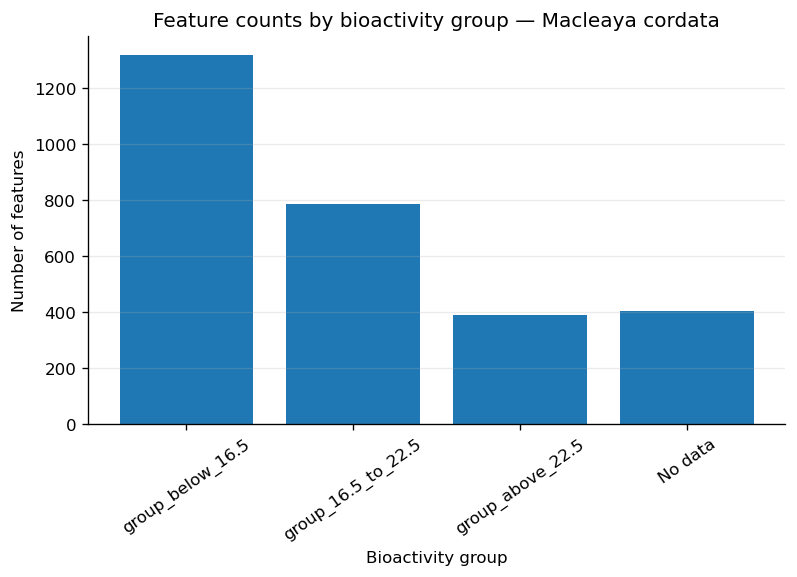

,group,feature_count
0,group_below_16.5,1319
1,group_16.5_to_22.5,785
2,group_above_22.5,391
3,No data,405


### Top mapped features

,row ID,row m/z,row retention time,predicted_hplc_rt,matched_fraction,bioactivity_group_Macleaya_cordata,bioactivity_value_Macleaya_cordata,20240813_60_s86t1_1uL.mzML Peak area
0,23987,356.290850,6.982864,11.004396,25,group_above_22.5,36.594199,1.007929e+04
1,23995,453.337072,6.984667,11.007501,25,group_above_22.5,36.594199,6.740391e+04
2,24004,849.391020,6.987863,11.013007,25,group_above_22.5,36.594199,3.137905e+05
3,24073,341.243638,7.005047,11.042611,25,group_above_22.5,36.594199,2.435391e+04
4,24110,333.215135,7.015964,11.061418,25,group_above_22.5,36.594199,2.575092e+04
5,24120,528.166387,7.019119,11.066854,25,group_above_22.5,36.594199,7.789066e+04
6,24170,533.259988,7.030318,11.086148,25,group_above_22.5,36.594199,1.522375e+04
7,24257,867.399494,7.047095,11.115051,25,group_above_22.5,36.594199,2.216896e+04
8,24276,729.171980,7.049142,11.118577,25,group_above_22.5,36.594199,4.985552e+04
9,24320,333.215157,7.056453,11.131172,25,group_above_22.5,36.594199,2.694065e+04


In [15]:
for plant_cfg in config["plants"]:
    plant_name = plant_cfg["name"]
    display(Markdown(f"## {plant_name}"))

    plant_df = plant_tables[plant_name]
    display(Markdown("### Fraction-level bioactivity"))
    plot_bioactivity_by_fraction(plant_df, plant_name, cutoffs)

    display(Markdown("### Feature counts by bioactivity group"))
    counts_df = plot_group_counts_for_plant(
        combined_df,
        plant_cfg,
        cutoffs=cutoffs,
        only_present=SHOW_ONLY_PRESENT_FEATURES,
    )
    display(counts_df)

    display(Markdown("### Top mapped features"))
    top_df = top_features_for_plant(
        combined_df,
        plant_cfg,
        top_n=TOP_N_FEATURES,
        only_present=SHOW_ONLY_PRESENT_FEATURES,
    )
    display(top_df)

## Optional appended feature table preview

This appears only if you used `append_to_feature_table` in the core config.

In [16]:
if appended_df is None:
    print("No appended feature table was produced in this run.")
else:
    display(appended_df.head(DISPLAY_ROWS))

,row ID,molecularFormula,NPC#pathway,NPC#superclass,NPC#class,Erythroxylum coca,Acanthus mollis,Thymus praecox,Monarda fistulosa,Satureja montana,...,Scutellaria altissima,Monarda citriodora,predicted_hplc_rt,matched_fraction,parsed_fraction_numbers,bioactivity_group_Macleaya_cordata,bioactivity_value_Macleaya_cordata,bioactivity_group_Macleaya_microcarpa,bioactivity_value_Macleaya_microcarpa,target_plant_status
0,1,C15H18O2,Terpenoids,Sesquiterpenoids,Eudesmane sesquiterpenoids,0.0000,0.00000,236.51025,970.4380,0.000,...,1669.4779,940.5805,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants
1,2,C9H25N5,Alkaloids,Ornithine alkaloids,Polyamines,157953.5000,0.00000,0.00000,0.0000,0.000,...,0.0000,0.0000,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants
2,3,C4H5Cl2FN2O5,Amino acids and Peptides,Fatty Acids and Conjugates,Halogenated fatty acids,0.0000,24615.26800,0.00000,0.0000,0.000,...,0.0000,0.0000,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants
3,4,C6H4Cl2N2O3,Polyketides,Nicotinic acid alkaloids,Pyridine alkaloids,0.0000,54819.89500,0.00000,0.0000,0.000,...,0.0000,0.0000,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants
4,5,C7H6BrFNO3,Amino acids and Peptides,Cyclic polyketides,Halogenated fatty acids,109780.4200,45790.40000,80833.81000,71840.8900,96511.875,...,42995.0300,72110.2900,0.48740123748560005,Fraction not collected,NaN,No data,Not present in target plants,No data,Not present in target plants,Present in target plants
5,6,C2H4F2N2O4S2,Alkaloids,Small peptides,Halogenated fatty acids,117232.9600,50707.41000,85279.36000,79150.9700,106926.610,...,48712.1170,75743.2700,0.4881240608200139,Fraction not collected,NaN,No data,Not present in target plants,No data,Not present in target plants,Present in target plants
6,7,C4H5BrFO3,Fatty acids,Fatty Acids and Conjugates,Halogenated fatty acids,44827.7900,16816.04100,32482.55900,15981.2350,38974.945,...,27311.6460,27905.3460,0.4893336188510742,Fraction not collected,NaN,No data,Not present in target plants,No data,Not present in target plants,Present in target plants
7,8,C4H4ClN2O3S2,Amino acids and Peptides,Histidine alkaloids,Imidazole alkaloids,67039.0400,42989.51000,49210.51000,43351.5350,57175.840,...,24821.5490,42559.0550,0.4896562078573641,Fraction not collected,NaN,No data,Not present in target plants,No data,Not present in target plants,Present in target plants
8,9,C3H7Cl2NO4Se,Amino acids and Peptides,Fatty Acids and Conjugates,Halogenated fatty acids,0.0000,132329.10000,0.00000,0.0000,0.000,...,0.0000,0.0000,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants
9,10,C2H6AsNO5,Fatty acids,Fatty Acids and Conjugates,Halogenated fatty acids,0.0000,106886.73400,0.00000,0.0000,0.000,...,0.0000,0.0000,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants,Not present in target plants
